In [1]:
import os
import numpy as np
import scipy.io.wavfile as wav
from sklearn import preprocessing
import joblib
from IPython import embed
import matplotlib.pyplot as plot
plot.switch_backend('agg')
import matplotlib.pyplot as plt
import sys
import pandas as pd

%matplotlib inline 

sys.path.insert(1, './seld-net')
import cls_feature_class

In [18]:
%tensorboard --logdir logs/fit

UsageError: Line magic function `%tensorboard` not found.


In [2]:
import parameter
params = parameter.get_params('9')

import cls_data_generator

data_gen_train = cls_data_generator.DataGenerator(
    dataset=params['dataset'], ov=params['overlap'], split=params['split'], db=params['db'], nfft=params['nfft'],
    batch_size=params['batch_size'], seq_len=params['sequence_length'], classifier_mode=params['mode'],
    weakness=params['weakness'], datagen_mode='train', cnn3d=params['cnn_3d'], xyz_def_zero=params['xyz_def_zero'],
    azi_only=params['azi_only']
)
result = next(data_gen_train.generate())
print(result[0].shape)

print(result[1][0].shape) #sed
print(result[1][1].shape) #doa

SET: 9
quick_test: False
azi_only: False
dataset: drone_filtered
overlap: 1
split: 1
db: 50
nfft: 512
sequence_length: 512
batch_size: 2
dropout_rate: 0.0
nb_cnn2d_filt: 64
pool_size: [8, 8, 2]
rnn_size: [128, 128]
fnn_size: [128]
loss_weights: [1.0, 50.0]
xyz_def_zero: True
nb_epochs: 1000
mode: regr
nb_cnn3d_filt: 32
cnn_3d: False
weakness: 0
patience: 100
Datagen_mode: train, nb_files: 240, nb_classes:1
nb_frames_file: 5166, feat_len: 256, nb_ch: 16, label_len:3

Dataset: drone_filtered, ov: 1, split: 1
batch_size: 2, seq_len: 512, shuffle: True
label_dir: ./dataset_generator/sounds/filtered_8_channel_microphone_signals/label_ov1_split1_nfft512_regr0
 feat_dir: ./dataset_generator/sounds/filtered_8_channel_microphone_signals/spec_ov1_split1_50db_nfft512_norm

(2, 16, 512, 256)
(2, 512, 1)
(2, 512, 3)


In [ ]:
class_name = cls_feature_class.FeatureClass(ov=1, nfft=512, dataset='drone', db=50)

unnormalized_dir = class_name.get_unnormalized_feat_dir()
normallized_dir = class_name.get_normalized_feat_dir()

In [5]:
spec_scaler = preprocessing.StandardScaler()
train_cnt = 0
for file_cnt, file_name in enumerate(os.listdir(unnormalized_dir)):
    if 'train' in file_name:
        print(file_cnt, train_cnt, file_name)
        feat_file = np.load(os.path.join(unnormalized_dir, file_name))
        spec_scaler.partial_fit(np.concatenate((np.abs(feat_file), np.angle(feat_file)), axis=1))
        del feat_file
        train_cnt += 1

60 0 train_1.wav.npy
61 1 train_10.wav.npy
62 2 train_100.wav.npy
63 3 train_101.wav.npy
64 4 train_102.wav.npy
65 5 train_103.wav.npy
66 6 train_104.wav.npy
67 7 train_105.wav.npy
68 8 train_106.wav.npy
69 9 train_107.wav.npy
70 10 train_108.wav.npy
71 11 train_109.wav.npy
72 12 train_11.wav.npy
73 13 train_110.wav.npy
74 14 train_111.wav.npy
75 15 train_112.wav.npy
76 16 train_113.wav.npy
77 17 train_114.wav.npy
78 18 train_115.wav.npy
79 19 train_116.wav.npy
80 20 train_117.wav.npy
81 21 train_118.wav.npy
82 22 train_119.wav.npy
83 23 train_12.wav.npy
84 24 train_120.wav.npy
85 25 train_121.wav.npy
86 26 train_122.wav.npy
87 27 train_123.wav.npy
88 28 train_124.wav.npy
89 29 train_125.wav.npy
90 30 train_126.wav.npy
91 31 train_127.wav.npy
92 32 train_128.wav.npy
93 33 train_129.wav.npy
94 34 train_13.wav.npy
95 35 train_130.wav.npy
96 36 train_131.wav.npy
97 37 train_132.wav.npy
98 38 train_133.wav.npy
99 39 train_134.wav.npy
100 40 train_135.wav.npy
101 41 train_136.wav.npy
102 42

In [3]:
feat_file = np.load(os.path.join(unnormalized_dir, file_name))
test = np.concatenate((np.abs(feat_file), np.angle(feat_file)), axis=1)

fig, ax = plt.subplots()
# Use the actual data array, not its shape
# ax.pcolormesh(test.T, shading='auto', cmap='inferno')
ax.pcolormesh(np.abs(feat_file[:2048, :]), shading='auto', cmap='inferno')

NameError: name 'unnormalized_dir' is not defined

In [127]:

fs = 44100
fft = 512
hop_len = fft
win_len = fft // 2
eps = 1e-16

def spectrogram(audio_input):
    nb_ch = audio_input.shape[1]
    nb_bins = fft // 2
    max_frames = int(np.ceil((audio_input.shape[0] - win_len) / float(hop_len)))
    hann_win = np.repeat(np.hanning(win_len)[np.newaxis].T, nb_ch, 1)
    spectra = np.zeros((max_frames, nb_bins, nb_ch), dtype=complex)
    for ind in range(max_frames):
        start_ind = ind * hop_len
        aud_frame = audio_input[start_ind + np.arange(0, win_len), :] * hann_win
        spectra[ind] = np.fft.fft(aud_frame, n=fft, axis=0, norm='ortho')[:nb_bins, :]
    return spectra


In [9]:
test.shape

(5166, 4096)

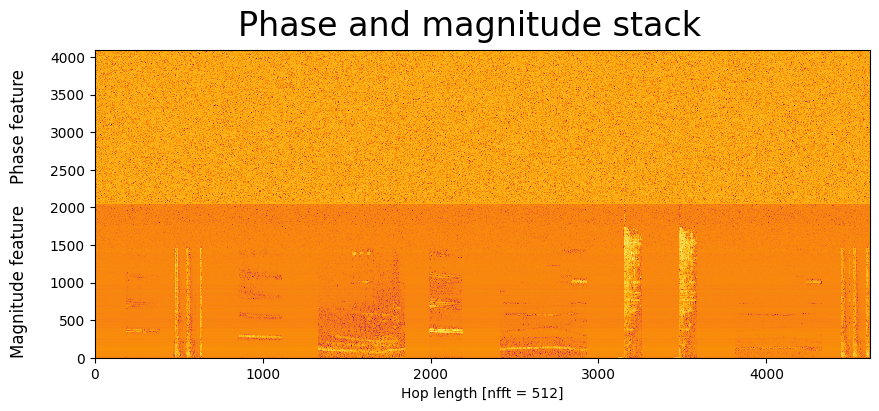

In [178]:
combined = np.load('./dataset_generator/sounds/criset_4class_20examples_1to10m/spec_ov1_split1_30db_nfft512_norm/test_2_desc_30_100.wav.npy')

%matplotlib inline 

fig, ax = plt.subplots(figsize=(10, 4))
ax.pcolormesh(10 * np.log10(np.abs(combined[:4614, :].T + 1e-9)), shading='auto', cmap='inferno')

ax.text(-450, 1024, 'Magnitude feature', fontsize=12, verticalalignment='center', horizontalalignment='center', rotation=90)
ax.text(-450, 3072, 'Phase feature', fontsize=12, verticalalignment='center', horizontalalignment='center', rotation=90)

plt.suptitle("Phase and magnitude stack", fontsize=24)
plt.xlabel('Hop length [nfft = 512]')
plt.show()

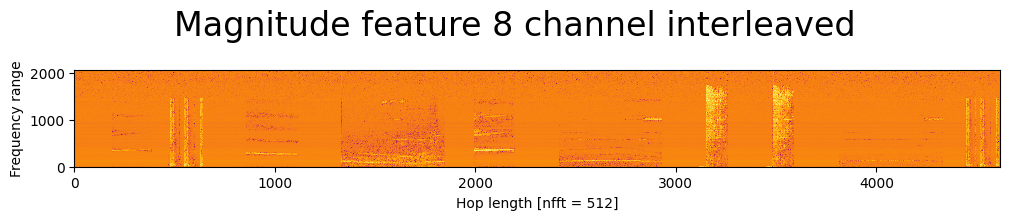

In [175]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.pcolormesh(10 * np.log10(np.abs(combined[:4614, :2048].T + 1e-9)), shading='auto', cmap='inferno')

plt.suptitle("Magnitude feature 8 channel interleaved", fontsize=24)
plt.tight_layout()
plt.xlabel('Hop length [nfft = 512]')
plt.ylabel('Frequency range')
plt.show()

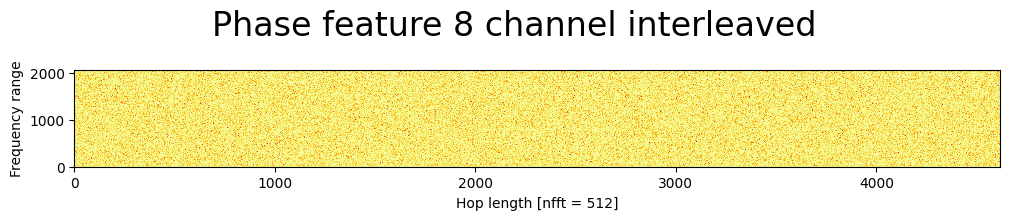

In [177]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.pcolormesh(10 * np.log10(np.abs(combined[:4614, 2048:].T + 1e-9)), shading='auto', cmap='inferno')

plt.suptitle("Phase feature 8 channel interleaved", fontsize=24)
plt.tight_layout()
plt.xlabel('Hop length [nfft = 512]')
plt.ylabel('Frequency range')
plt.show()

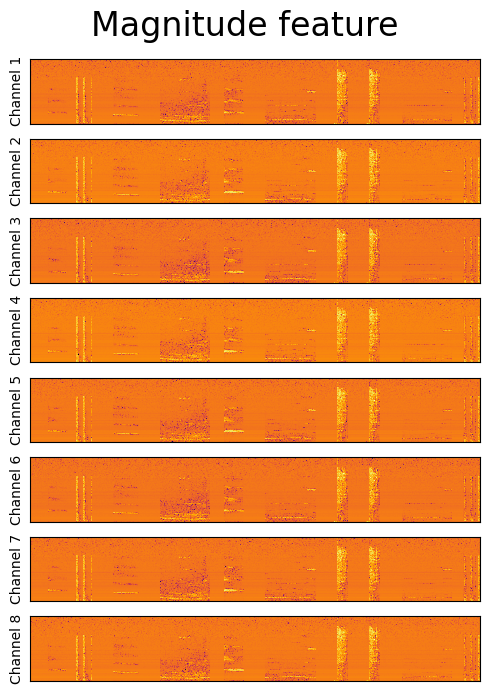

In [171]:
fig, ax = plt.subplots((8), figsize=(5, 7))

for channel in range(8): # 8 channels
    magnitude = 10 * np.log10(np.abs(combined[:4614, :2048].T + 1e-9))
    ax[channel].pcolormesh(magnitude[channel::8], shading='auto', cmap='inferno')
    ax[channel].set_ylabel(f"Channel {channel + 1}")
    ax[channel].set_xticks([])  # Remove x-axis ticks
    ax[channel].set_yticks([])  # Remove y-axis ticks

plt.suptitle("Magnitude feature", fontsize=24)
plt.tight_layout()
plt.show()

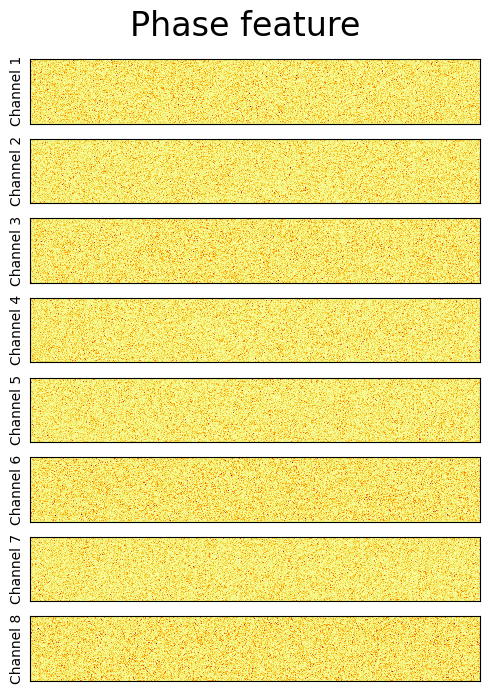

In [179]:
fig, ax = plt.subplots((8), figsize=(5, 7))

for channel in range(8): # 8 channels
    phase = 10 * np.log10(np.abs(combined[:4614, 2048:].T + 1e-9))
    ax[channel].pcolormesh(phase[channel::8], shading='auto', cmap='inferno')
    ax[channel].set_ylabel(f"Channel {channel + 1}")
    ax[channel].set_xticks([])  # Remove x-axis ticks
    ax[channel].set_yticks([])  # Remove y-axis ticks

plt.suptitle("Phase feature", fontsize=24)
plt.tight_layout()
plt.show()

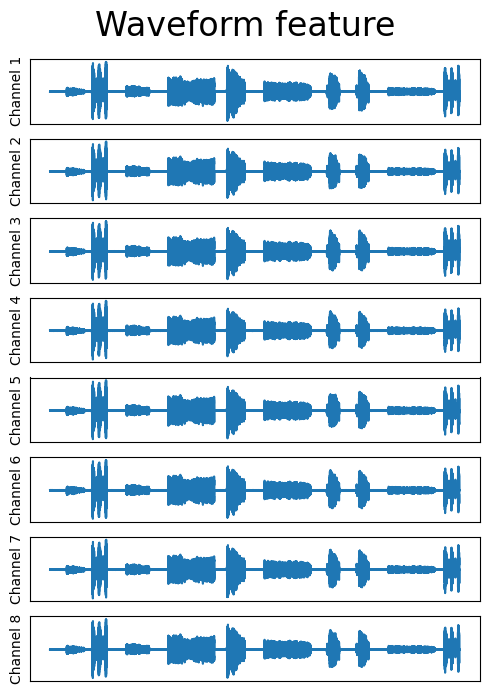

In [180]:
rs, waveform = wav.read('./dataset_generator/sounds/criset_4class_20examples_1to10m/wav_ov1_split1_30db/test_2_desc_30_100.wav')

cmap = plt.cm.inferno  # You can use other colormaps as well (e.g., 'plasma', 'viridis')

fig, ax = plt.subplots((8), figsize=(5, 7))
for channel in range(waveform.shape[1]):
    ax[channel].plot(waveform[:, channel])
    ax[channel].set_ylabel(f"Channel {channel + 1}")
    ax[channel].set_xticks([])  # Remove x-axis ticks
    ax[channel].set_yticks([])  # Remove y-axis ticks

plt.suptitle("Waveform feature", fontsize=24)
plt.tight_layout()
plt.show()

In [129]:
a.shape

(2307, 256, 8)

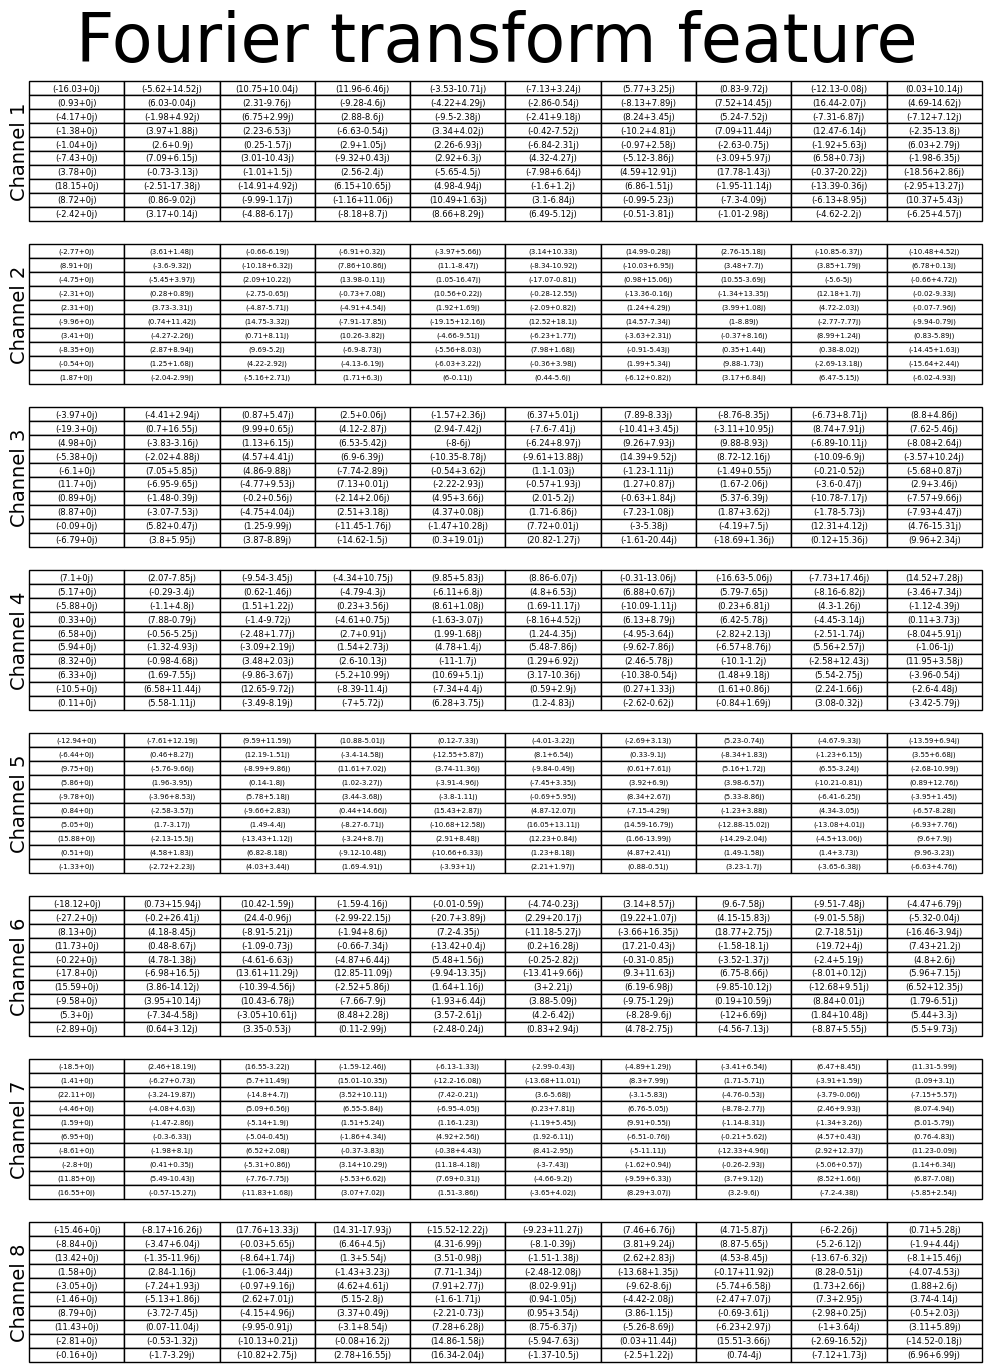

In [181]:
# Example 10x10 array
arr = np.random.randn(10, 10)


a = spectrogram(waveform)
fig, ax = plt.subplots(8, figsize=(10, 14))

for channel in range(8):
    ax[channel].axis('off')
    ax[channel].table(cellText=a[:10, :10, channel].round(2).astype(str), loc='center', cellLoc='center')
    ax[channel].set_ylabel(f"Channel {channel + 1}")
    ax[channel].text(-0.01, 0.5, f"Channel {channel + 1}", ha='center', va='center', fontsize=14, rotation=90)

# Adjust layout
plt.suptitle("Fourier transform feature", fontsize=48)
plt.tight_layout()
plt.show()


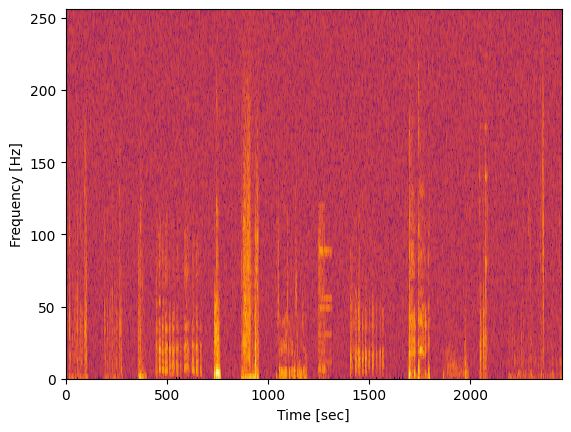

In [ ]:
fs, a = wav.read('./dataset_generator/ANSIM_clone_matlab/dataset_generator/sounds/ANSIM_clone/wav_ov1_split1_30db/test_0_desc_30_100.wav')
audio = a[:, :4] / 32768.0 + eps

a = spectrogram(a)

%matplotlib inline 

fig, ax = plt.subplots()
ax.pcolormesh(10 * np.log10(np.abs(a[:, :, 0].T + 1e-9)), shading='auto', cmap='inferno')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

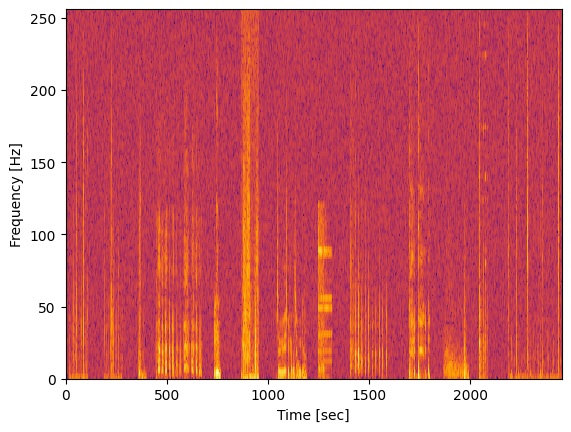

In [96]:
fs, b = wav.read('./dataset_generator/sounds/ANSIM/wav_ov1_split1_30db/test_0_desc_30_100.wav')
audio = b[:, :4] / 32768.0 + eps

b = spectrogram(b)

%matplotlib inline 

fig, ax = plt.subplots()
ax.pcolormesh(10 * np.log10(np.abs(b[:, :, 0].T + 1e-9)), shading='auto', cmap='inferno')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()